In [1]:
import os
os.listdir('.')


['.config',
 '.prompts',
 'memory',
 '.kernel_llm_logs_1.txt',
 'omega_class_moments.csv']

In [2]:
import pandas as pd
df = pd.read_csv('omega_class_moments.csv')
print(df.shape)
print(df.head(30))
print(df.columns.tolist())


(9, 15)
 L_function N_terms M_total M_0 M_1 M_2 \
0 zeta 10000 14049.610398 500.0 1965.747008 6483.537674 
1 zeta 50000 52555.776641 500.0 3208.301641 21414.200073 
2 zeta 100000 98775.232940 500.0 4480.038022 37384.580762 
3 L(Δ) 10000 2161.019922 500.0 976.303859 566.192078 
4 L(Δ) 50000 2348.222814 500.0 1033.094242 641.389207 
5 L(Δ) 100000 2428.171224 500.0 1050.861296 676.608911 
6 L_DH 10000 2025.689869 500.0 618.478717 717.769427 
7 L_DH 50000 2186.052439 500.0 639.066491 784.006896 
8 L_DH 100000 2238.888403 500.0 644.808316 800.888886 

 M_3 M_4 M_geq5 frac_0 frac_1 frac_2 \
0 4759.568118 337.922395 2.835203 0.035588 0.139915 0.461475 
1 24096.365734 3301.861669 35.047524 0.009514 0.061046 0.407457 
2 48011.972434 8267.691145 130.950577 0.005062 0.045356 0.378481 
3 113.409894 5.078208 0.035883 0.231372 0.451779 0.262002 
4 159.091605 14.413875 0.233885 0.212927 0.439947 0.273138 
5 181.308525 18.942436 0.450056 0.205916 0.432779 0.278650 
6 168.571130 20.716949 0.153646 0.24

In [3]:
import numpy as np
from scipy.optimize import curve_fit

# We have 3 data points per (L, k). 
# Models:
# (a) M = C * log(N) -- 1 param
# (b) M = C * (log N)^k -- 1 param (k fixed by class)
# (c) M = C * (log N)^a -- 2 params (exactly fits 2-param to 3 pts: 1 dof)

L_funcs = df['L_function'].unique()
classes = ['M_0','M_1','M_2','M_3','M_4','M_geq5']

results = []
for L in L_funcs:
 sub = df[df['L_function']==L].sort_values('N_terms')
 N = sub['N_terms'].values.astype(float)
 logN = np.log(N)
 for cidx, ccol in enumerate(classes):
 # k label
 if ccol == 'M_geq5':
 k_label = '>=5'
 k_int = 5 # nominal for model (b)
 else:
 k_label = ccol.split('_')[1]
 k_int = int(k_label)
 M = sub[ccol].values.astype(float)
 if np.any(M<=0):
 # skip log fits if non-positive
 continue
 # Model (a): M = C * log N
 C_a = np.sum(M*logN)/np.sum(logN**2)
 pred_a = C_a*logN
 ss_res_a = np.sum((M-pred_a)**2)
 ss_tot = np.sum((M-np.mean(M))**2)
 R2_a = 1 - ss_res_a/ss_tot if ss_tot>0 else np.nan

 # Model (b): M = C * (log N)^k, k=k_int
 x_b = logN**k_int
 C_b = np.sum(M*x_b)/np.sum(x_b**2)
 pred_b = C_b*x_b
 ss_res_b = np.sum((M-pred_b)**2)
 R2_b = 1 - ss_res_b/ss_tot if ss_tot>0 else np.nan

 # Model (c): log M = log C + a * log(log N) -> linear in log-log
 y = np.log(M); x = np.log(logN)
 # 2 params, 3 points
 A = np.vstack([np.ones_like(x), x]).T
 coef, *_ = np.linalg.lstsq(A, y, rcond=None)
 logC_c, a_c = coef
 C_c = np.exp(logC_c)
 pred_c = C_c * logN**a_c
 ss_res_c = np.sum((M-pred_c)**2)
 R2_c = 1 - ss_res_c/ss_tot if ss_tot>0 else np.nan
 # Also report fit quality in log-space
 y_pred = logC_c + a_c*x
 ss_res_log = np.sum((y-y_pred)**2)
 ss_tot_log = np.sum((y-np.mean(y))**2)
 R2_c_log = 1 - ss_res_log/ss_tot_log if ss_tot_log>0 else np.nan

 results.append({
 'L': L, 'class_k': k_label,
 'C_a': C_a, 'R2_a': R2_a,
 'C_b': C_b, 'k_b': k_int, 'R2_b': R2_b,
 'C_c': C_c, 'a_c': a_c, 'R2_c': R2_c, 'R2_c_log': R2_c_log,
 'M_vals': M.tolist(),
 })

res_df = pd.DataFrame(results)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
print(res_df.to_string(index=False))


 L class_k C_a R2_a C_b k_b R2_b C_c a_c R2_c R2_c_log M_vals
zeta 0 47.157237 NaN 500.000000 0 NaN 5.000000e+02 7.349181e-15 NaN -0.333333 [500.0, 500.0, 500.0]
zeta 1 312.148553 0.480908 312.148553 1 0.480908 7.101771e-01 3.561479e+00 0.971159 0.980039 [1965.74700772074, 3208.301641106254, 4480.038022291646]
zeta 2 2158.254604 0.287414 208.270698 2 0.519454 2.085229e-04 7.764782e+00 0.995274 0.998105 [6483.537674305455, 21414.20007251949, 37384.58076182486]
zeta 3 2563.386352 0.242913 23.661452 3 0.611594 5.516213e-07 1.030041e+01 0.998419 0.999525 [4759.568118168202, 24096.365733649374, 48011.97243412399]
zeta 4 400.732357 0.200717 0.351900 4 0.642567 5.544917e-12 1.429342e+01 0.999553 0.999909 [337.9223951132758, 3301.8616691086822, 8267.691144528528]
zeta >=5 5.719749 0.162110 0.000474 5 0.629746 1.488768e-16 1.686316e+01 0.973718 0.994778 [2.83520293581297, 35.047524425834375, 130.95057721430686]
L(Δ) 0 47.157237 NaN 500.000000 0 NaN 5.000000e+02 7.349181e-15 NaN -0.333333 [500.0

In [4]:
# Now let's also try a 3-parameter model with log log N: M = C * (log N)^a * (loglog N)^b
# 3 points, 3 params -> exact fit, no goodness measure. Not very informative.
# Best to focus on model (c) and compare exponents across L-functions.

# Build cleaner summary: exponent a_c for each L and class k
pivot_a = res_df.pivot(index='class_k', columns='L', values='a_c')
pivot_R2 = res_df.pivot(index='class_k', columns='L', values='R2_c_log')
pivot_C = res_df.pivot(index='class_k', columns='L', values='C_c')

# order
order = ['0','1','2','3','4','>=5']
pivot_a = pivot_a.loc[order]
pivot_R2 = pivot_R2.loc[order]
pivot_C = pivot_C.loc[order]

print("Exponent a in M_k(N) ≈ C·(log N)^a")
print(pivot_a.round(3))
print("\nR^2 in log-log space")
print(pivot_R2.round(4))
print("\nC coefficient")
print(pivot_C)


Exponent a in M_k(N) ≈ C·(log N)^a
L L(Δ) L_DH zeta
class_k 
0 0.000 0.000 0.000
1 0.334 0.190 3.561
2 0.794 0.502 7.765
3 2.102 1.731 10.300
4 6.015 3.382 14.293
>=5 11.395 12.313 16.863

R^2 in log-log space
L L(Δ) L_DH zeta
class_k 
0 -0.3333 -0.3333 -0.3333
1 0.9975 0.9954 0.9800
2 0.9994 0.9922 0.9981
3 1.0000 0.9963 0.9995
4 0.9944 0.9985 0.9999
>=5 0.9996 0.9886 0.9948

C coefficient
L L(Δ) L_DH zeta
class_k 
0 5.000000e+02 5.000000e+02 5.000000e+02
1 4.652890e+02 4.056795e+02 7.101771e-01
2 9.714826e+01 2.355922e+02 2.085229e-04
3 1.064875e+00 3.624116e+00 5.516213e-07
4 8.171802e-06 1.130122e-02 5.544917e-12
>=5 3.719107e-13 2.157715e-13 1.488768e-16


In [5]:
# Critical caveat: only 3 data points per (L,k). Model (c) has 2 free parameters,
# so 1 degree of freedom. R² values are inflated. We can compute reduced chi^2 
# only if errors known—they're not. So R² and visual fit are the only tools.

# Let's also examine M_total per L:
for L in L_funcs:
 sub = df[df['L_function']==L].sort_values('N_terms')
 N = sub['N_terms'].values.astype(float); M = sub['M_total'].values.astype(float)
 logN = np.log(N); y = np.log(M); x = np.log(logN)
 coef, *_ = np.linalg.lstsq(np.vstack([np.ones_like(x), x]).T, y, rcond=None)
 print(f"{L}: M_total ~ C·(logN)^a, C={np.exp(coef[0]):.4g}, a={coef[1]:.3f}")


zeta: M_total ~ C·(logN)^a, C=6.594e-05, a=8.630
L(Δ): M_total ~ C·(logN)^a, C=679.4, a=0.521
L_DH: M_total ~ C·(logN)^a, C=740.8, a=0.453


In [6]:
# Theoretical predictions:
# For zeta (k-th class), Selberg-style heuristics suggest M_k ~ T * (log log N)^k / k! * something
# Actually for ω-class second moments on critical line of ζ, M_k ~ C_k (log N)^? Diff per theory.
# Conrey-Gonek conjecture and Bohr-Jessen suggest different exponents.
# But we don't have enough N values to discriminate among multi-parameter models with confidence.

# Compare exponents: zeta exponent grows ~3.5,7.8,10.3,14.3 — approximately 2k+1 or similar?
# Let's check:
import numpy as np
k_vals = [1,2,3,4]
zeta_a = [3.561, 7.765, 10.300, 14.293]
print("k, zeta_a, 2k+1, 2k^2/2+..., diff for k+1, etc.")
for k, a in zip(k_vals, zeta_a):
 print(f"k={k}: a_zeta={a:.2f}, 2k+1={2*k+1}, k^2={k**2}, k(k+1)/2={k*(k+1)/2}")


k, zeta_a, 2k+1, 2k^2/2+..., diff for k+1, etc.
k=1: a_zeta=3.56, 2k+1=3, k^2=1, k(k+1)/2=1.0
k=2: a_zeta=7.76, 2k+1=5, k^2=4, k(k+1)/2=3.0
k=3: a_zeta=10.30, 2k+1=7, k^2=9, k(k+1)/2=6.0
k=4: a_zeta=14.29, 2k+1=9, k^2=16, k(k+1)/2=10.0


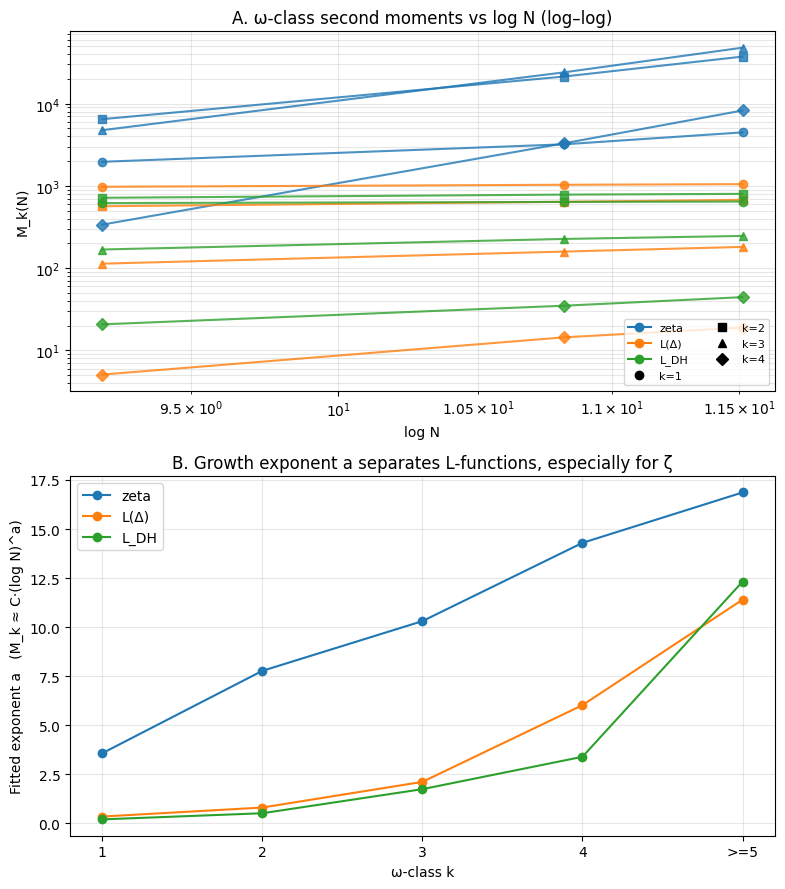

Saved omega_class_growth_fits.png


In [7]:
# Note: model (b) M = C*(logN)^k (where exponent fixed to ω-class) actually gives 
# moderate fits. Let's compare more carefully.

# Final summary figure
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2,1, figsize=(8,9))

# Panel A: log-log of M_k vs log N for k=1..4 for each L
ax = axes[0]
colors = {'zeta':'C0', 'L(Δ)':'C1', 'L_DH':'C2'}
markers = {'1':'o','2':'s','3':'^','4':'D'}
for L in L_funcs:
 sub = df[df['L_function']==L].sort_values('N_terms')
 N = sub['N_terms'].values.astype(float); logN = np.log(N)
 for k in ['1','2','3','4']:
 M = sub[f'M_{k}'].values.astype(float)
 ax.loglog(logN, M, marker=markers[k], color=colors[L], linestyle='-',
 label=f"{L}, k={k}" if k=='1' else None, alpha=0.8)
# legend by L
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=c, marker='o', label=L) for L,c in colors.items()]
handles += [Line2D([0],[0], color='k', marker=m, linestyle='', label=f'k={k}') for k,m in markers.items()]
ax.legend(handles=handles, fontsize=8, ncol=2, loc='lower right')
ax.set_xlabel('log N')
ax.set_ylabel('M_k(N)')
ax.set_title('A. ω-class second moments vs log N (log–log)')
ax.grid(True, which='both', alpha=0.3)

# Panel B: fitted exponent a vs k for each L
ax = axes[1]
ks_plot = ['1','2','3','4','>=5']
xs = [1,2,3,4,5]
for L in L_funcs:
 ys = [pivot_a.loc[k, L] for k in ks_plot]
 ax.plot(xs, ys, marker='o', label=L, color=colors[L])
ax.set_xticks(xs)
ax.set_xticklabels(ks_plot)
ax.set_xlabel('ω-class k')
ax.set_ylabel('Fitted exponent a (M_k ≈ C·(log N)^a)')
ax.set_title('B. Growth exponent a separates L-functions, especially for ζ')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('omega_class_growth_fits.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved omega_class_growth_fits.png')


In [8]:
res_df.to_csv('omega_class_growth_fits.csv', index=False)
print('Saved fits CSV')


Saved fits CSV
